In [5]:
import scanpy as sc
from pathlib import Path

# ---------- 0. 读取 ----------
ref   = sc.read_h5ad(Path("D:/Data/M-MG_cleaned.h5ad"))
query = sc.read_h5ad(Path("D:/Data/M-MG_track_cleaned.h5ad"))

# ---------- 1. 统一 cluster 列 ----------
# 若 ref 已有 cluster，可跳过这一行
ref.obs["cluster"] = ref.obs['newcelltype']
# query 用 subtype 作为 cluster 标签
query.obs["cluster"] = query.obs["subtype"]

In [12]:
query.obs['cluster'].unique()

['Basal-Myo-Mature', 'LumSEC-Lac-B', 'B-Cell', 'T-NK', 'Pericyte', ..., 'LumSEC-Lac-ECM', 'Mammary-Adipocyte', 'Myeloid-MacDC', 'Endothelial', 'Basal-Myo-Precursor']
Length: 13
Categories (12, object): ['B-Cell', 'Basal-Myo-Mature', 'Basal-Myo-Precursor', 'Endothelial', ..., 'Myeloid-MacDC', 'Pericyte', 'Stromal-Fibroblast', 'T-NK']

In [3]:
ref.obs

,sample,n_genes_by_counts,total_counts,doublet_score,predicted_doublet,gland,stage_old,log1p_n_genes_by_counts,log1p_total_counts,total_counts_MT,...,species,celltype,stage,cellid,initial_size_unspliced,initial_size_spliced,initial_size,newcelltype,subtype,cluster
cellid,,,,,,,,,,,,,,,,,,,,,
M-MG-3WK-1-AATGGCTCATGCAGCC,M-MG-3WK-1,3866,14729.0,0.086822,False,MG,stage2,8.260234,9.597642,147.0,...,M,Luminal epithelial cells,stage1,M-MG-3WK-1-AATGGCTCATGCAGCC,3467,9600,9600.0,LumHR,LuminalEpithelialCells,LumHR
M-MG-3WK-1-ATTGTTCCAAGTGGCA,M-MG-3WK-1,3360,10403.0,0.154512,False,MG,stage2,8.119994,9.249946,320.0,...,M,Basal epithelial cells,stage1,M-MG-3WK-1-ATTGTTCCAAGTGGCA,2463,6652,6652.0,MaSC,BasalEpithelialCells,MaSC
M-MG-3WK-1-CATGCAACACTAGGCC,M-MG-3WK-1,2637,6782.0,0.097540,False,MG,stage2,7.877776,8.822175,77.0,...,M,Luminal epithelial cells,stage1,M-MG-3WK-1-CATGCAACACTAGGCC,2501,3551,3551.0,Lum-Kit,LuminalEpithelialCells,Lum-Kit
M-MG-3WK-1-CTAGGTAAGAGCAGAA,M-MG-3WK-1,2765,6524.0,0.097540,False,MG,stage2,7.925158,8.783397,145.0,...,M,Luminal epithelial cells,stage1,M-MG-3WK-1-CTAGGTAAGAGCAGAA,4145,1692,1692.0,MaSC-Pro,LuminalEpithelialCells,MaSC-Pro
M-MG-3WK-1-GATAGAACATTGGGAG,M-MG-3WK-1,4578,20119.0,0.086822,False,MG,stage2,8.429236,9.909470,303.0,...,M,Luminal epithelial cells,stage1,M-MG-3WK-1-GATAGAACATTGGGAG,3987,13805,13805.0,LumHR,LuminalEpithelialCells,LumHR
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
M-MG-P1-TTGGGATTCCCTCTCC,M-MG-P1,3357,11844.0,0.105882,False,MG,stage2,8.119101,9.379662,112.0,...,M,Basal epithelial cells,stage1,M-MG-P1-TTGGGATTCCCTCTCC,4235,6302,6302.0,MaSC,BasalEpithelialCells,MaSC
M-MG-P1-TTGGGTAAGGCTCTAT,M-MG-P1,2571,6366.0,0.020874,False,MG,stage2,7.852439,8.758883,47.0,...,M,Basal epithelial cells,stage1,M-MG-P1-TTGGGTAAGGCTCTAT,1930,3749,3749.0,Lum-Kit,LuminalEpithelialCells,Lum-Kit
M-MG-P1-TTGTGGATCGCCTAGG,M-MG-P1,3077,10044.0,0.034167,False,MG,stage2,8.032035,9.214830,75.0,...,M,Basal epithelial cells,stage1,M-MG-P1-TTGTGGATCGCCTAGG,1940,6811,6811.0,MaSC,LuminalEpithelialCells,MaSC


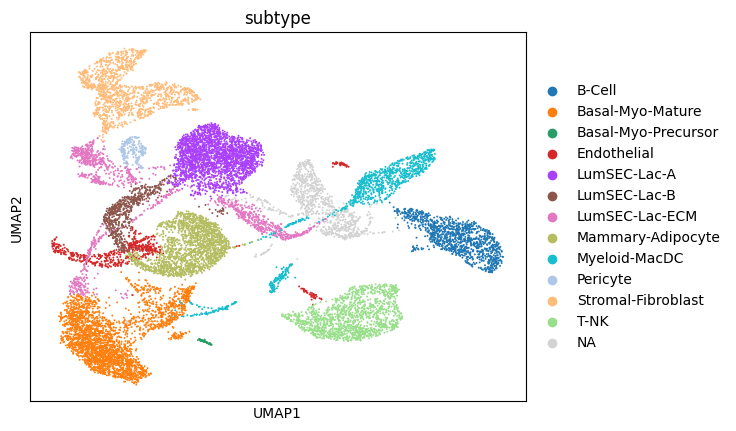

In [9]:
sc.pl.umap(query,color=['subtype'])

In [2]:
keep_subtypes = ["LumSEC-Lac-Prime",
    "LumSEC-Progenitor",                 
    "LumSEC-Progenitor-t2",        
    "Lum-Basal",
    'Lum-Krt1',
    "Basal-Myo-Mature",
    "Basal‑Progenitor","MaSC-like" ]   # ←自行修改
query_sub = query[query.obs["subtype"].isin(keep_subtypes)].copy()
query_sub.obs['DEG-celltype']=query_sub.obs['subtype']
ref.obs['DEG-celltype']=ref.obs['newcelltype']

In [6]:
# ---------- 3. Ensembl ID 对齐 -----------
ref.var["ensembl"]   = ref.var["Accession"]                     # ref 已为 Ensembl
query_sub.var["ensembl"] = query_sub.var["gene_ids"]     # ← 确认列名无误

import pandas as pd
common_genes = pd.Index(ref.var["ensembl"]).intersection(query_sub.var["ensembl"])
print("共有基因数量:", len(common_genes))

# 按共同基因子集并统一顺序
genes = list(common_genes)              # 保持 Index → list 顺序
ref_aln   = ref
query_aln = query_sub[:, query_sub.var["ensembl"].isin(genes)].copy()


print("对齐后尺寸:", ref_aln.shape, query_aln.shape)


共有基因数量: 12088
对齐后尺寸: (10880, 12088) (8760, 12088)


In [7]:
query_aln.var

,gene_ids,feature_types,genome,gene_name,mt,n_cells_by_counts,mean_counts,pct_dropout_by_counts,total_counts,highly_variable,means,dispersions,dispersions_norm,mean,std,ensembl
gene_ids,,,,,,,,,,,,,,,,
ENSMUSG00000025900,ENSMUSG00000025900,Gene Expression,mm10,Rp1,False,2,0.000128,99.987221,2.0,False,5.531496e-05,-0.857429,-2.438839,0.000046,0.004038,ENSMUSG00000025900
ENSMUSG00000025902,ENSMUSG00000025902,Gene Expression,mm10,Sox17,False,1448,0.144591,90.748195,2263.0,False,1.267395e-01,0.927576,0.920837,0.074304,0.263730,ENSMUSG00000025902
ENSMUSG00000033845,ENSMUSG00000033845,Gene Expression,mm10,Mrpl15,False,1812,0.132452,88.422465,2073.0,False,1.050047e-01,0.489290,0.095909,0.070123,0.224474,ENSMUSG00000033845
ENSMUSG00000002459,ENSMUSG00000002459,Gene Expression,mm10,Rgs20,False,47,0.004153,99.699700,65.0,False,3.519755e-03,0.868271,0.809214,0.002014,0.043592,ENSMUSG00000002459
ENSMUSG00000033793,ENSMUSG00000033793,Gene Expression,mm10,Atp6v1h,False,1105,0.077759,92.939748,1217.0,False,6.782815e-02,0.630454,0.361604,0.043575,0.183028,ENSMUSG00000033793
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSMUSG00000031352,ENSMUSG00000031352,Gene Expression,mm10,Hccs,False,203,0.013290,98.702958,208.0,False,1.253887e-02,0.537348,0.186362,0.008043,0.078679,ENSMUSG00000031352
ENSMUSG00000064351,ENSMUSG00000064351,Gene Expression,mm10,mt-Co1,False,3093,0.328605,80.237684,5143.0,False,1.956457e-01,0.814574,0.708149,0.127055,0.309440,ENSMUSG00000064351
ENSMUSG00000064367,ENSMUSG00000064367,Gene Expression,mm10,mt-Nd5,False,306,0.020702,98.044853,324.0,False,1.788221e-02,0.766947,0.618507,0.011053,0.094144,ENSMUSG00000064367


In [8]:
ref_aln.var

,Accession,Chromosome,End,Start,Strand,highly_variable,means,dispersions,dispersions_norm,mean,std,ensembl
Rp1,ENSMUSG00000025900,1,4409241,3999557,-,True,0.013444,0.568251,1.045748,0.008446,0.082446,ENSMUSG00000025900
Sox17,ENSMUSG00000025902,1,4497354,4490931,-,False,0.004698,0.291383,0.487246,0.003181,0.046713,ENSMUSG00000025902
Mrpl15,ENSMUSG00000033845,1,4785739,4773206,-,False,0.203417,-0.300062,-1.169970,0.164867,0.256967,ENSMUSG00000033845
Rgs20,ENSMUSG00000002459,1,5070285,4909576,-,True,0.405357,0.855509,0.911276,0.274207,0.445594,ENSMUSG00000002459
Atp6v1h,ENSMUSG00000033793,1,5162529,5070018,+,False,0.356479,0.513431,0.611198,0.265962,0.377812,ENSMUSG00000033793
...,...,...,...,...,...,...,...,...,...,...,...,...
Msl3,ENSMUSG00000031358,X,168673898,168654117,-,False,0.128012,-0.219598,-0.543514,0.101905,0.206359,ENSMUSG00000031358
Hccs,ENSMUSG00000031352,X,169320372,169250193,-,False,0.060048,0.179538,0.261630,0.044559,0.150918,ENSMUSG00000031352
mt-Co1,ENSMUSG00000064351,M,6872,5328,+,True,4.039324,3.655645,1.000000,3.672763,0.966367,ENSMUSG00000064351
mt-Nd5,ENSMUSG00000064367,M,13565,11742,+,False,1.448537,1.163773,-0.799930,1.223932,0.669150,ENSMUSG00000064367


In [9]:
import pandas as pd

# =========================
# 1. 处理 query_aln
# =========================
# ---- obs 仅留 celltype / subtype / cluster ----
q_keep_obs  = ['celltype', 'DEG-celltype', 'cluster','bc']
query_aln.obs = query_aln.obs[q_keep_obs].copy()

# ---- var 仅留 gene_ids / gene_name / ensembl ----
q_keep_var = ['gene_ids', 'gene_name', 'ensembl']
# 若 gene_name 不存在，用原 var_names 补上
if 'gene_name' not in query_aln.var.columns:
    query_aln.var['gene_name'] = query_aln.var_names
query_aln.var = query_aln.var[q_keep_var].copy()

# 确保 var_names == ensembl
query_aln.var_names = query_aln.var['ensembl']
print("query_aln 处理后:", query_aln)

query_aln 处理后: AnnData object with n_obs × n_vars = 8760 × 12088
    obs: 'celltype', 'DEG-celltype', 'cluster', 'bc'
    var: 'gene_ids', 'gene_name', 'ensembl'
    uns: 'celltype_colors', 'dendrogram_leiden', 'hvg', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'rank_genes_groups', 'scrublet', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts', 'normalized'
    obsp: 'connectivities', 'distances'


In [18]:
# =========================
# 2. 处理 ref_aln
# =========================
# ---- obs 仅留 sample / stage / newcelltype / subtype / cluster ----
r_keep_obs = ['sample', 'stage', 'DEG-celltype','cluster','cellid']
ref_aln.obs = ref_aln.obs[r_keep_obs].copy()

# ---- var: 先保存 gene_name，再仅留 Accession / ensembl / gene_name ----
ref_aln.var['gene_name'] = ref_aln.var_names          # 先写入 gene_name
r_keep_var = ['Accession', 'ensembl', 'gene_name']
# 若 ensembl 列丢失，用 Accession 暂充
if 'ensembl' not in ref_aln.var.columns:
    ref_aln.var['ensembl'] = ref_aln.var['Accession']
ref_aln.var = ref_aln.var[r_keep_var].copy()

# 把 var_names 改成 ensembl
ref_aln.var_names = ref_aln.var['ensembl']
keep_layers = {'counts', 'normalized'}
for k in list(ref_aln.layers.keys()):  # 用 list() 防止迭代时修改大小
    if k not in keep_layers:
        del ref_aln.layers[k]
print("ref_aln 处理后:", ref_aln)

ref_aln 处理后: AnnData object with n_obs × n_vars = 10880 × 12088
    obs: 'sample', 'stage', 'DEG-celltype', 'cluster', 'cellid'
    var: 'Accession', 'ensembl', 'gene_name'
    uns: 'dendrogram_leiden', 'gland_colors', 'hvg', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'newcelltype_colors', 'pca', 'rank_genes_groups', 'sample_colors', 'stage_colors', 'subtype_colors', 'umap'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap'
    varm: 'PCs'
    layers: 'counts', 'normalized'
    obsp: 'connectivities', 'distances'


In [19]:
ref_aln.layers

Layers with keys: counts, normalized

In [20]:
# =========================
# 3. 简单一致性检查
# =========================
assert set(ref_aln.var_names) == set(query_aln.var_names), "基因集不一致！"
print("✓ 两对象基因集一致，总基因数:", len(ref_aln.var_names))

✓ 两对象基因集一致，总基因数: 12088


In [21]:
ref_aln.write('D:/Data/M-MG_ref.h5ad')
query_aln.write('D:/Data/M-MG_query.h5ad')